In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import joblib

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Semua library berhasil di-import!")

✅ Semua library berhasil di-import!


Clustering Finansial Mahasiswa — Versi Indonesia (IDR)
=======================================================
Perubahan dari versi sebelumnya:
  1. Konversi USD → IDR dengan rasio penyesuaian konteks Indonesia
  2. Financial Health Score (0–100) per mahasiswa
  3. Kategorisasi status: Bahaya / Waspada / Stabil / Sangat Sehat
  4. Visualisasi distribusi status per cluster (pie + bar + stacked bar)
  5. Semua label grafik sudah menggunakan satuan Rupiah

In [2]:
import kagglehub, os

path = kagglehub.dataset_download("sumanthnimmagadda/student-spending-dataset")
df_raw = pd.read_csv(f"{path}/student_spending (1).csv")

df = df_raw.rename(columns={
    'Unnamed: 0'     : 'id',
    'age'            : 'usia',
    'monthly_income' : 'pendapatan',
    'financial_aid'  : 'bantuan',
    'tuition'        : 'pendidikan',
    'housing'        : 'tempat_tinggal',
    'food'           : 'makanan',
    'transportation' : 'transportasi',
    'books_supplies' : 'buku',
    'entertainment'  : 'hiburan',
    'personal_care'  : 'perawatan',
    'technology'     : 'teknologi',
    'health_wellness': 'kesehatan',
    'miscellaneous'  : 'lainnya'
})

Using Colab cache for faster access to the 'student-spending-dataset' dataset.


In [3]:
# ============================================================
# KONVERSI USD → IDR (KONTEKS MAHASISWA INDONESIA)
# Kurs USD/IDR: Rp 18,035 (Google Finance, 4 Jun 2026 — realtime)
# Dataset asli: mahasiswa AS (income ~$600–1500/bln)
# Disesuaikan ke konteks Indonesia:
#   - Income target: Rp 2–7 juta/bln (uang saku + beasiswa)
#   - Pengeluaran disesuaikan biaya hidup kota mahasiswa Indonesia
# ============================================================

KURS_USD_IDR = 18_035   # kurs realtime USD/IDR, Juni 2026
INCOME_SCALE = 0.20     # PPP adjustment: konversi income ke standar Indonesia

# --- Pemasukan ---
income_cols = ['pendapatan', 'bantuan']
for col in income_cols:
    if col in df.columns:
        df[col] = (df[col] * KURS_USD_IDR * INCOME_SCALE).round(0)

# --- Pengeluaran (rasio disesuaikan biaya hidup mahasiswa Indonesia) ---
# Referensi: BPS 2023, survei kos mahasiswa kota besar Indonesia
RASIO = {
    'pendidikan'     : 0.037,  # UKT/bln ~300–600rb
    'tempat_tinggal' : 0.063,  # kos ~600rb–1.5jt
    'makanan'        : 0.059,  # makan 3x ~700rb–1.2jt
    'transportasi'   : 0.049,  # bensin/ojol ~250–600rb
    'buku'           : 0.028,  # buku/fotokopi ~80–200rb
    'hiburan'        : 0.055,  # hiburan ~150–350rb
    'perawatan'      : 0.042,  # perawatan diri ~120–300rb
    'teknologi'      : 0.037,  # kuota/aksesori ~150–400rb
    'kesehatan'      : 0.028,  # obat/klinik ~80–200rb
    'lainnya'        : 0.042,  # lain-lain ~120–300rb
}

for col, rasio_val in RASIO.items():
    if col in df.columns:
        if col == 'pendidikan':
            # Biaya pendidikan dibagi 6 (per bulan dari semester)
            df[col] = (df[col] / 6 * KURS_USD_IDR * rasio_val).round(0)
        else:
            df[col] = (df[col] * KURS_USD_IDR * rasio_val).round(0)

print("\u2705 Konversi USD \u2192 IDR (konteks mahasiswa Indonesia) berhasil!")
print(f"   Kurs referensi  : 1 USD = Rp {KURS_USD_IDR:,}  (Google Finance, 4 Jun 2026)")
print(f"   Income scale    : {INCOME_SCALE} (penyesuaian PPP + daya beli Indonesia)")
print(f"   Target income   : Rp 2\u20137 juta per bulan")
print(f"   Target pengelrn : Rp 1.5\u20134 juta per bulan")


✅ Konversi USD → IDR (konteks mahasiswa Indonesia) berhasil!
   Kurs referensi  : 1 USD = Rp 18,035  (Google Finance, 4 Jun 2026)
   Income scale    : 0.2 (penyesuaian PPP + daya beli Indonesia)
   Target income   : Rp 2–7 juta per bulan
   Target pengelrn : Rp 1.5–4 juta per bulan


In [4]:
df['total_pemasukan']   = df['pendapatan'] + df['bantuan']
df['total_pengeluaran'] = (df['pendidikan'] + df['tempat_tinggal'] + df['makanan'] +
                           df['transportasi'] + df['buku'] + df['hiburan'] +
                           df['perawatan'] + df['teknologi'] + df['kesehatan'] + df['lainnya'])
df['sisa_uang']         = df['total_pemasukan'] - df['total_pengeluaran']
df['rasio_pengeluaran'] = df['total_pengeluaran'] / df['total_pemasukan'].replace(0, np.nan)

print(f"\n✅ Data berhasil dimuat. Baris: {len(df)}, Kolom: {df.shape[1]}")
df.head()


✅ Data berhasil dimuat. Baris: 1000, Kolom: 22


,id,usia,gender,year_in_school,major,pendapatan,bantuan,pendidikan,tempat_tinggal,makanan,...,hiburan,perawatan,teknologi,kesehatan,lainnya,preferred_payment_method,total_pemasukan,total_pengeluaran,sisa_uang,rasio_pengeluaran
0,0,19,Non-binary,Freshman,Psychology,3455506.0,973890.0,660511.0,805569.0,314963.0,...,40669.0,59083.0,89418.0,64132.0,54538.0,Credit/Debit Card,4429396.0,2292516.0,2136880.0,0.517569
1,1,24,Female,Junior,Economics,3628642.0,3156125.0,545847.0,632866.0,388384.0,...,73402.0,69687.0,150809.0,65142.0,51508.0,Credit/Debit Card,6784767.0,2180016.0,4604751.0,0.321310
2,2,24,Non-binary,Junior,Economics,2647538.0,3347296.0,339320.0,756713.0,234094.0,...,128950.0,17422.0,159484.0,56558.0,100744.0,Cash,5994834.0,1964347.0,4030487.0,0.327673
3,3,23,Female,Senior,Computer Science,2225519.0,955855.0,548850.0,740806.0,307515.0,...,98201.0,22724.0,108769.0,53023.0,41661.0,Mobile Payment App,3181374.0,2134904.0,1046470.0,0.671064
4,4,20,Female,Senior,Computer Science,2921670.0,1882854.0,432296.0,937369.0,395832.0,...,47612.0,53780.0,58722.0,35854.0,78777.0,Credit/Debit Card,4804524.0,2286672.0,2517852.0,0.475941


In [5]:
def hitung_financial_score(row):
    total_peng = row['total_pengeluaran']
    total_in   = row['total_pemasukan']

    if total_in > 0:
        rasio_tabungan = max(0, min(1, row['sisa_uang'] / total_in))
    else:
        rasio_tabungan = 0
    skor_a = rasio_tabungan * 100

    esensial = row['tempat_tinggal'] + row['makanan'] + row['transportasi']
    if total_peng > 0:
        rasio_esensial = esensial / total_peng
        skor_b = rasio_esensial * 100
    else:
        skor_b = 50

    if total_peng > 0:
        buffer_ratio = max(0, min(1, row['sisa_uang'] / total_peng))
    else:
        buffer_ratio = 0
    skor_c = buffer_ratio * 100

    skor_total = 0.40 * skor_a + 0.30 * skor_b + 0.30 * skor_c
    return round(skor_total, 2)

# Hitung dulu financial_score-nya
df['financial_score'] = df.apply(hitung_financial_score, axis=1)

# Baru hitung threshold dari data aktual
_p25 = df['financial_score'].quantile(0.25)
_p50 = df['financial_score'].quantile(0.50)
_p75 = df['financial_score'].quantile(0.75)

print(f"\n📊 Threshold otomatis:")
print(f"   Bahaya      : < {_p25:.1f}")
print(f"   Waspada     : {_p25:.1f} – {_p50:.1f}")
print(f"   Stabil      : {_p50:.1f} – {_p75:.1f}")
print(f"   Sangat Sehat: ≥ {_p75:.1f}")

def get_status(score):
    if score >= _p75:
        return "Sangat Sehat"
    elif score >= _p50:
        return "Stabil"
    elif score >= _p25:
        return "Waspada"
    else:
        return "Bahaya"

df['status_finansial'] = df['financial_score'].apply(get_status)

STATUS_ORDER  = ["Bahaya", "Waspada", "Stabil", "Sangat Sehat"]
STATUS_COLORS = {"Bahaya": "#E63946", "Waspada": "#F4A261",
                 "Stabil": "#E9C46A", "Sangat Sehat": "#2A9D8F"}

print("\n📊 DISTRIBUSI STATUS FINANSIAL (keseluruhan data):")
dist_status = df['status_finansial'].value_counts().reindex(STATUS_ORDER, fill_value=0)
dist_pct    = (dist_status / len(df) * 100).round(2)
for s in STATUS_ORDER:
    bar = "█" * int(dist_pct[s] / 2)
    print(f"   {s:<14} : {dist_status[s]:>4} mahasiswa ({dist_pct[s]:>5.1f}%)  {bar}")


📊 Threshold otomatis:
   Bahaya      : < 66.1
   Waspada     : 66.1 – 70.4
   Stabil      : 70.4 – 73.3
   Sangat Sehat: ≥ 73.3

📊 DISTRIBUSI STATUS FINANSIAL (keseluruhan data):
   Bahaya         :  250 mahasiswa ( 25.0%)  ████████████
   Waspada        :  250 mahasiswa ( 25.0%)  ████████████
   Stabil         :  249 mahasiswa ( 24.9%)  ████████████
   Sangat Sehat   :  251 mahasiswa ( 25.1%)  ████████████


In [6]:
# 5. EDA — KUALITAS DATA
# ==============================================================================
print("\n" + "=" * 55)
print("🔍  LAPORAN KUALITAS DATA")
print("=" * 55)

missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
kualitas    = pd.DataFrame({"Jumlah Kosong": missing, "Persentase (%)": missing_pct})
kualitas    = kualitas[kualitas["Jumlah Kosong"] > 0]

if kualitas.empty:
    print("✅  Tidak ada nilai kosong (missing value) di dataset ini!")
else:
    print("⚠️  Kolom yang punya nilai kosong:")
    print(kualitas)

duplikat = df.duplicated().sum()
print(f"\n{'✅' if duplikat == 0 else '⚠️'}  Jumlah baris duplikat: {duplikat}")
print("=" * 55)


🔍  LAPORAN KUALITAS DATA
✅  Tidak ada nilai kosong (missing value) di dataset ini!

✅  Jumlah baris duplikat: 0


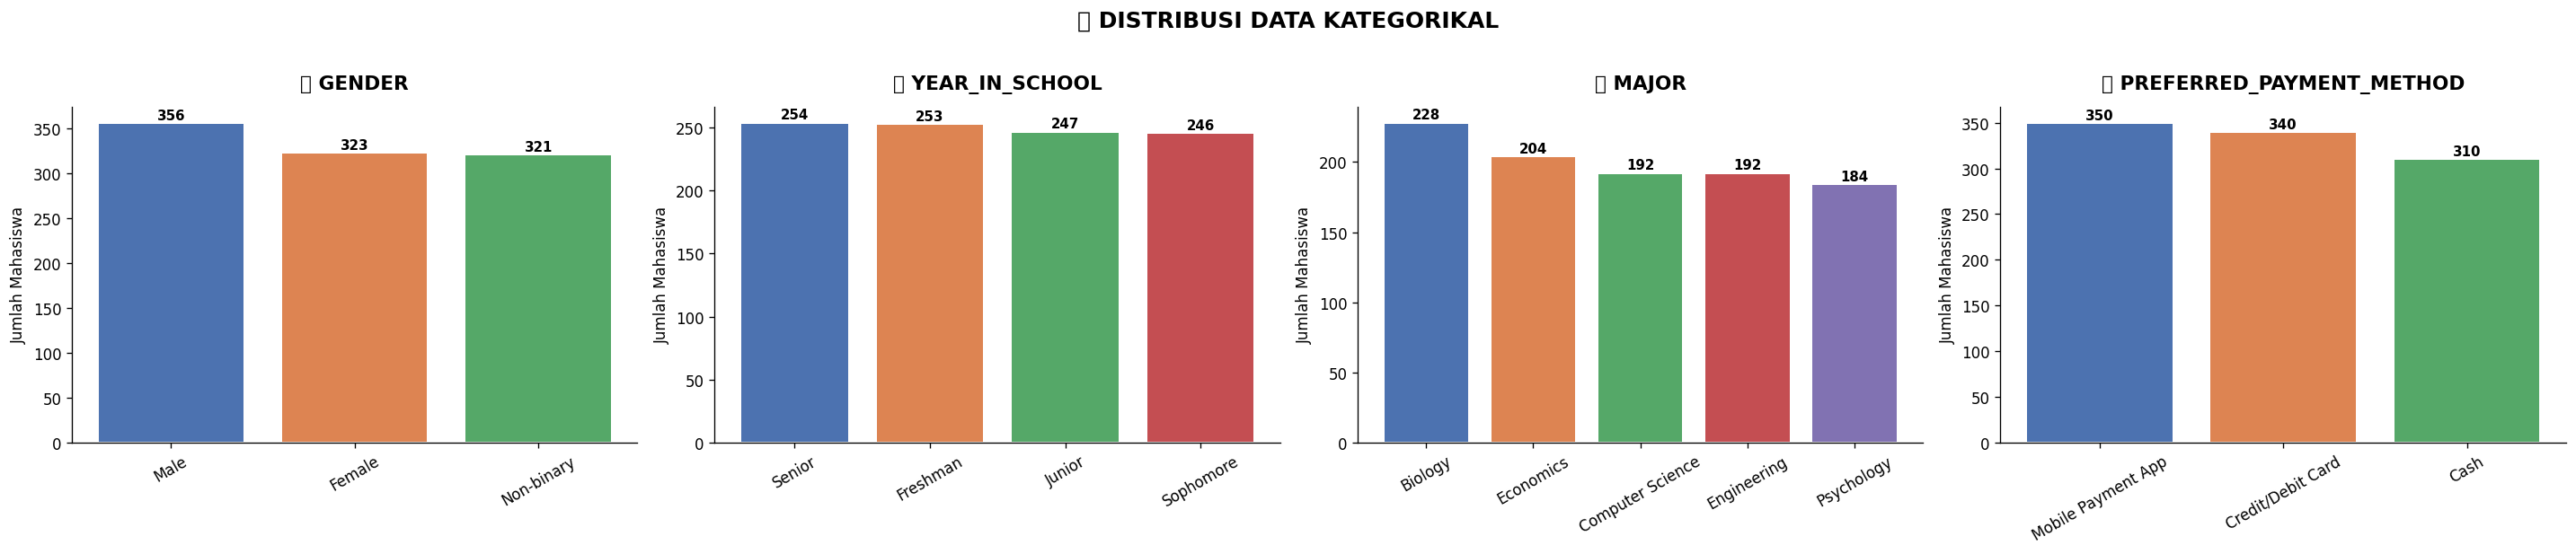

In [7]:
# 6. EDA — DISTRIBUSI KATEGORIKAL
# ==============================================================================
categorical_cols = df.select_dtypes(include='object').columns.tolist()
# Exclude kolom hasil kita sendiri untuk chart ini
categorical_cols = [c for c in categorical_cols if c not in ['status_finansial', 'nama_cluster']]

if len(categorical_cols) > 0:
    n = len(categorical_cols)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

    for ax, col in zip(axes, categorical_cols):
        counts = df[col].value_counts()
        bars = ax.bar(counts.index, counts.values,
                      color=COLORS[:len(counts)], edgecolor='white', linewidth=1.2)
        ax.set_title(f'📌 {col.upper()}', fontsize=13, fontweight='bold', pad=12)
        ax.set_ylabel('Jumlah Mahasiswa', fontsize=10)
        ax.tick_params(axis='x', rotation=30)
        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f'{val}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.spines[['top','right']].set_visible(False)

    fig.suptitle('📊 DISTRIBUSI DATA KATEGORIKAL', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

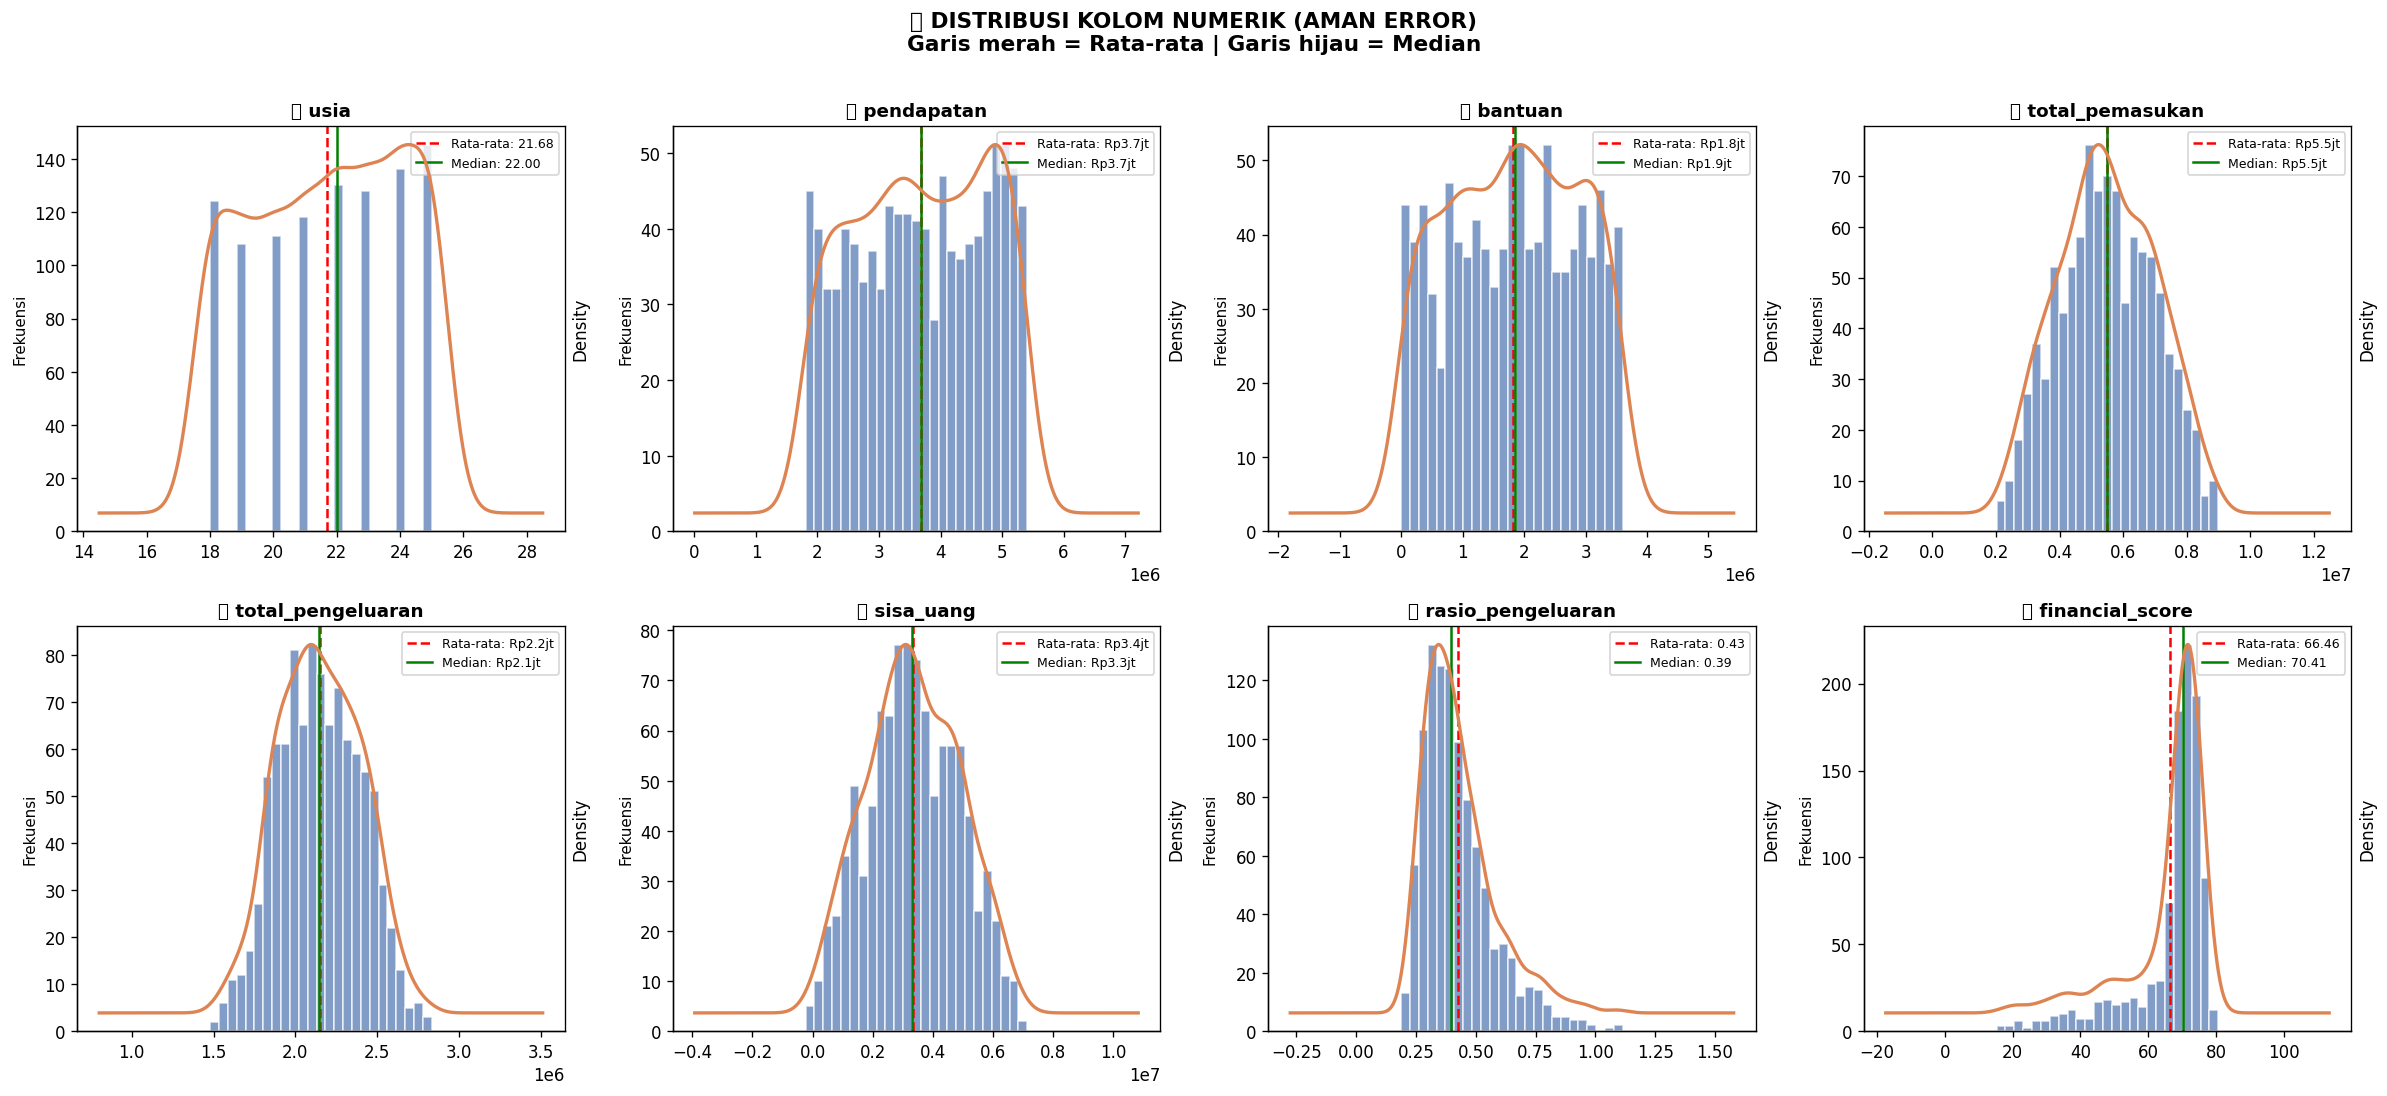

In [8]:
# ==============================================================================
# 7. EDA — DISTRIBUSI NUMERIK (AMAN DARI ERROR KDE)
# ==============================================================================

numerik_utama = ['usia', 'pendapatan', 'bantuan', 'total_pemasukan',
                 'total_pengeluaran', 'sisa_uang', 'rasio_pengeluaran', 'financial_score']

numerik_utama = [c for c in numerik_utama if c in df.columns]

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

def fmt_rupiah_short(val):
    if pd.isna(val):
        return "NA"
    if val >= 1_000_000:
        return f"Rp{val/1_000_000:.1f}jt"
    elif val >= 1_000:
        return f"Rp{val/1_000:.0f}rb"
    else:
        return f"{val:.2f}"

for i, col in enumerate(numerik_utama):
    ax = axes[i]
    data_col = df[col].dropna()

    # histogram
    ax.hist(data_col, bins=25, color='#4C72B0', alpha=0.7, edgecolor='white')

    # KDE aman (FIX ERROR UTAMA)
    ax2 = ax.twinx()
    ax2.set_yticks([])

    if data_col.nunique() > 1 and len(data_col) > 1:
        try:
            data_col.plot.kde(ax=ax2, color='#DD8452', linewidth=2)
        except:
            pass  # kalau masih error, skip saja
    else:
        ax2.text(0.5, 0.5, 'No KDE',
                 ha='center', va='center', transform=ax2.transAxes,
                 fontsize=8, color='gray')

    # mean & median
    mean_val = data_col.mean()
    median_val = data_col.median()

    lbl_mean = fmt_rupiah_short(mean_val) if col not in ['usia','rasio_pengeluaran','financial_score'] else f"{mean_val:.2f}"
    lbl_median = fmt_rupiah_short(median_val) if col not in ['usia','rasio_pengeluaran','financial_score'] else f"{median_val:.2f}"

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Rata-rata: {lbl_mean}')
    ax.axvline(median_val, color='green', linestyle='-',
               linewidth=1.5, label=f'Median: {lbl_median}')

    ax.set_title(f'📈 {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frekuensi', fontsize=9)
    ax.legend(fontsize=7.5, loc='upper right')
    ax.spines[['top','right']].set_visible(False)

# hide subplot kosong
for j in range(len(numerik_utama), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    '📊 DISTRIBUSI KOLOM NUMERIK (AMAN ERROR)\n'
    'Garis merah = Rata-rata | Garis hijau = Median',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

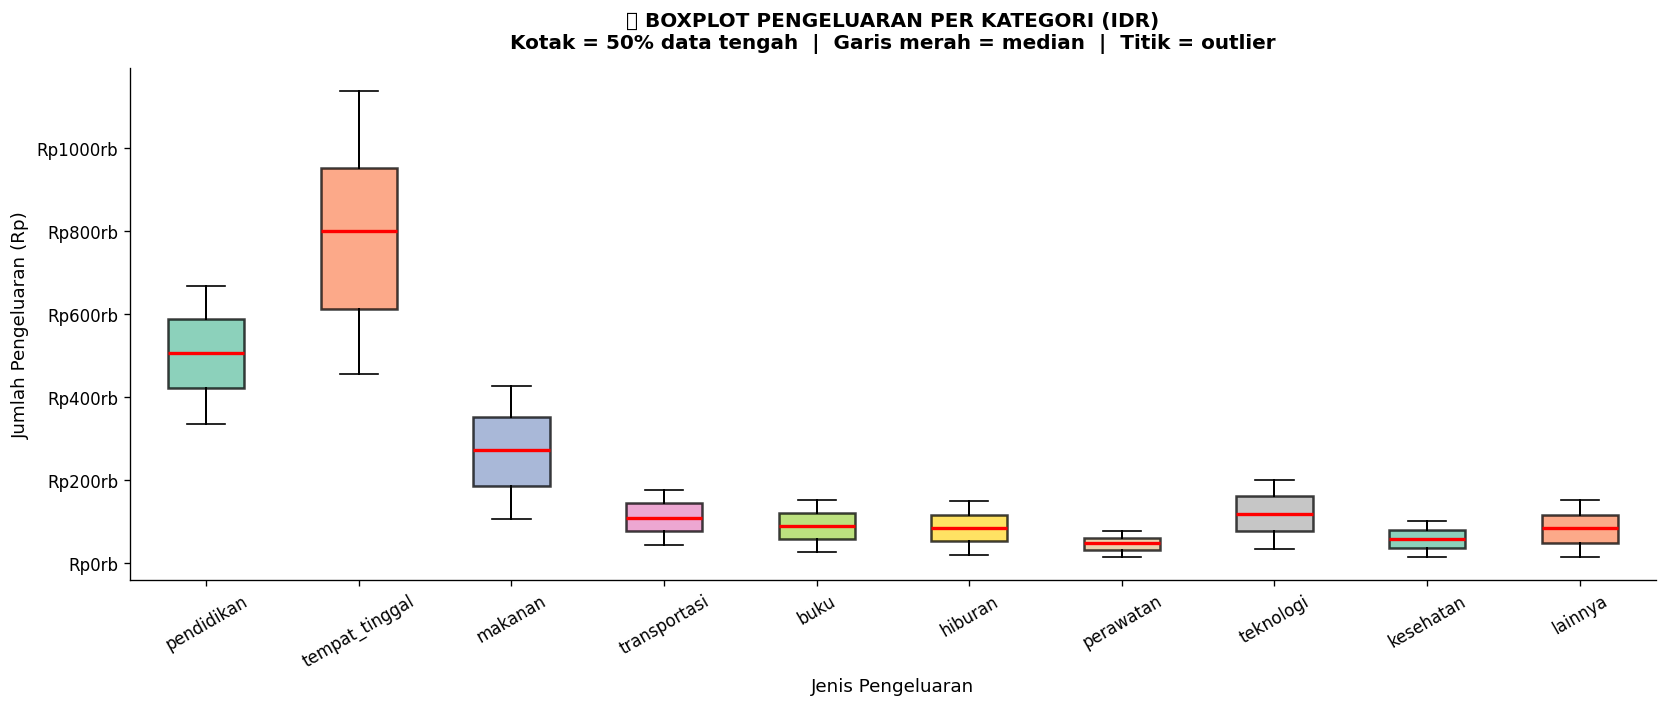

In [9]:
# 8. EDA — BOXPLOT PENGELUARAN (IDR)
# ==============================================================================
pengeluaran_cols = ['pendidikan','tempat_tinggal','makanan','transportasi',
                    'buku','hiburan','perawatan','teknologi','kesehatan','lainnya']
pengeluaran_cols = [c for c in pengeluaran_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(
    [df[c].dropna() for c in pengeluaran_cols],
    labels=pengeluaran_cols,
    patch_artist=True,
    medianprops=dict(color='red', linewidth=2),
    boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4, color='gray')
)
palette = sns.color_palette("Set2", len(pengeluaran_cols))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title('📦 BOXPLOT PENGELUARAN PER KATEGORI (IDR)\n'
             'Kotak = 50% data tengah  |  Garis merah = median  |  Titik = outlier',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Jenis Pengeluaran', fontsize=11)
ax.set_ylabel('Jumlah Pengeluaran (Rp)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"Rp{x/1_000:.0f}rb"))
ax.tick_params(axis='x', rotation=30)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


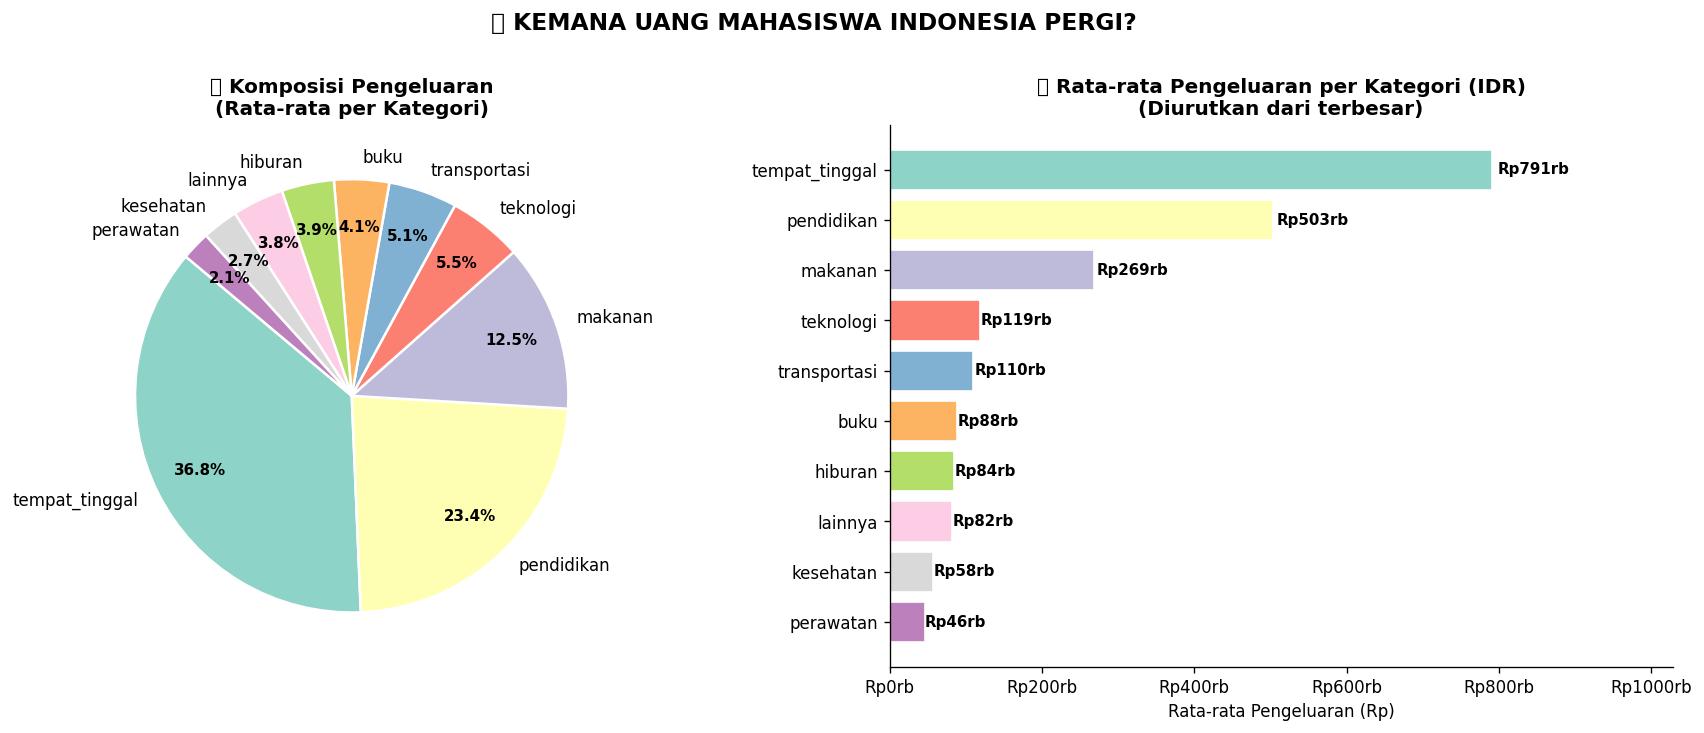

In [10]:
# 9. EDA — PIE & BAR PENGELUARAN (IDR)
# ==============================================================================
rata_pengeluaran = df[pengeluaran_cols].mean().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

colors_pie = sns.color_palette("Set3", len(rata_pengeluaran))
wedges, texts, autotexts = ax1.pie(
    rata_pengeluaran,
    labels=rata_pengeluaran.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
ax1.set_title('🥧 Komposisi Pengeluaran\n(Rata-rata per Kategori)', fontsize=12, fontweight='bold')

bars = ax2.barh(rata_pengeluaran.index[::-1], rata_pengeluaran.values[::-1],
                color=colors_pie[::-1], edgecolor='white')
for bar, val in zip(bars, rata_pengeluaran.values[::-1]):
    ax2.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
             f'Rp{val/1_000:.0f}rb', va='center', fontsize=9, fontweight='bold')
ax2.set_title('📊 Rata-rata Pengeluaran per Kategori (IDR)\n(Diurutkan dari terbesar)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Rata-rata Pengeluaran (Rp)', fontsize=10)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"Rp{x/1_000:.0f}rb"))
ax2.spines[['top','right']].set_visible(False)
ax2.set_xlim(0, rata_pengeluaran.max() * 1.3)

fig.suptitle('💰 KEMANA UANG MAHASISWA INDONESIA PERGI?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

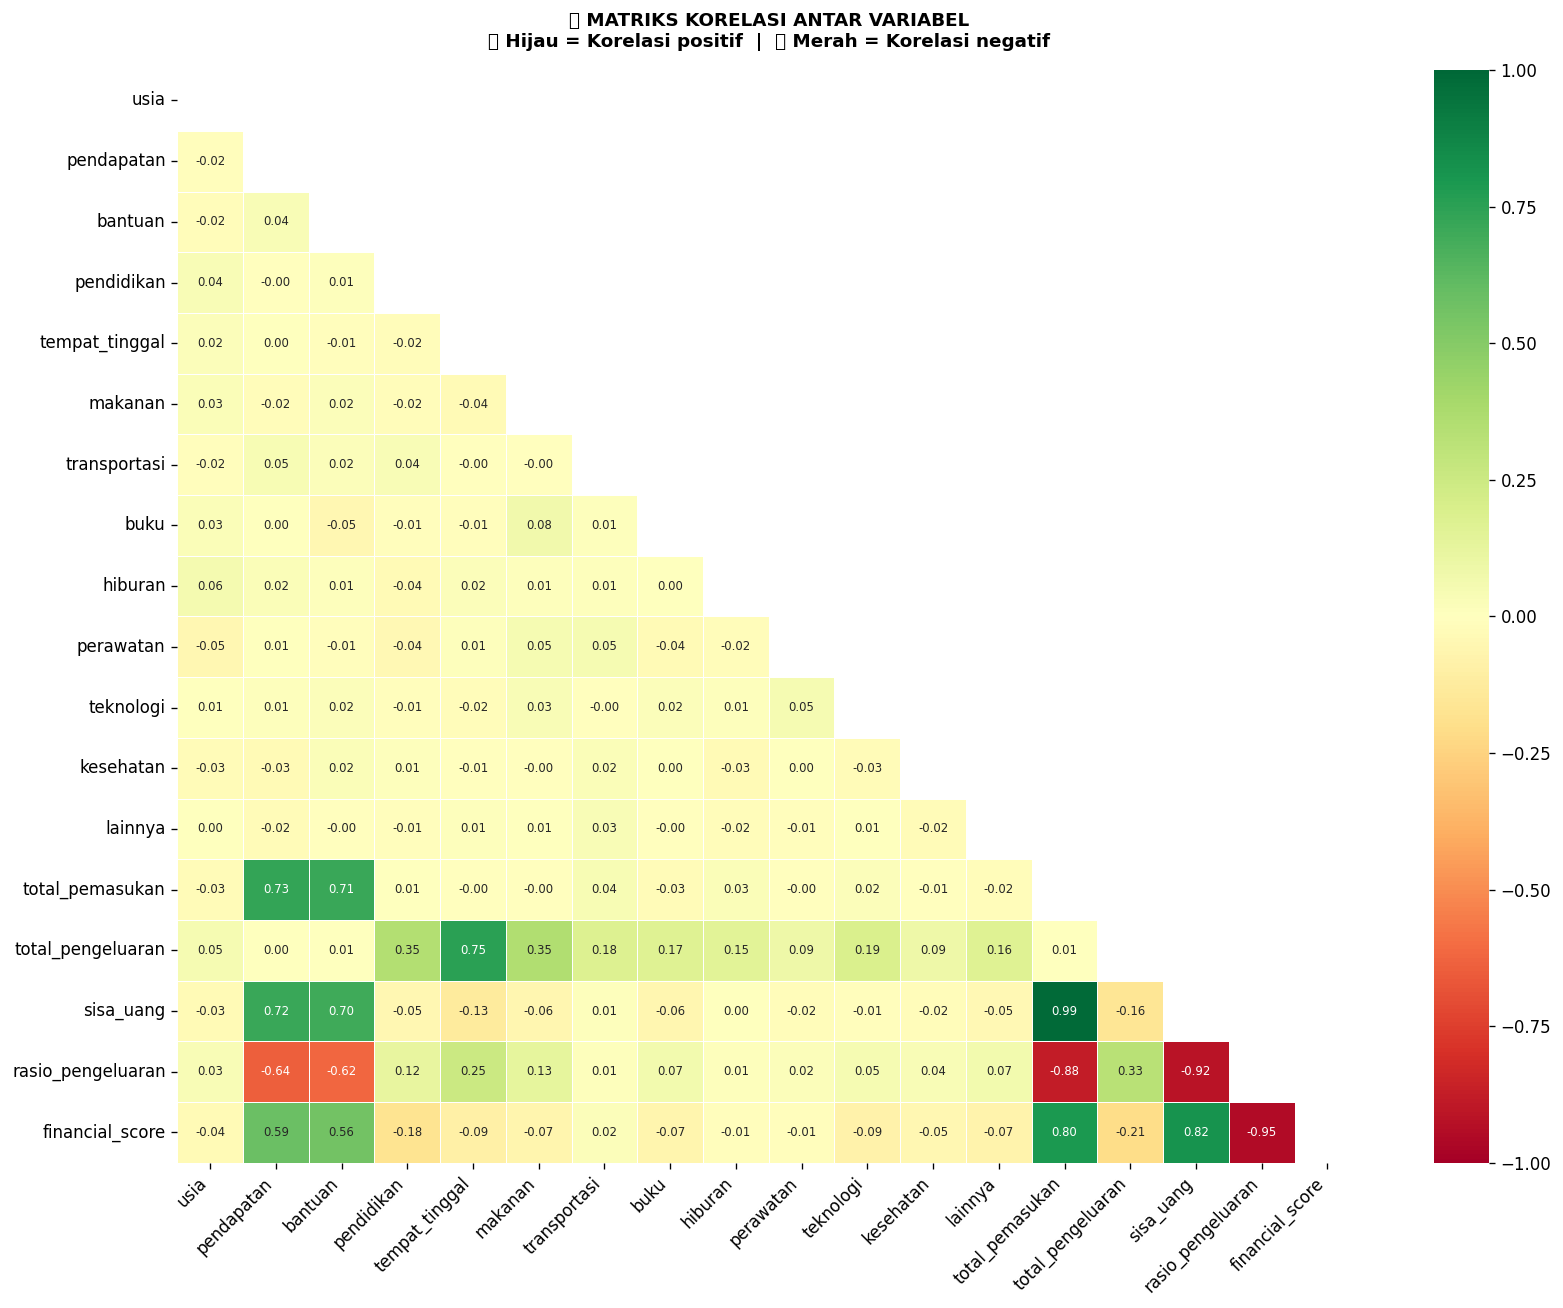

In [11]:
# 10. EDA — KORELASI
# ==============================================================================
numerical_cols = df.drop(columns=['id'], errors='ignore').select_dtypes(include='number').columns
correlation = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(
    correlation, mask=mask, annot=True, cmap='RdYlGn',
    fmt=".2f", vmin=-1, vmax=1, linewidths=0.5,
    linecolor='white', annot_kws={"size": 7}, ax=ax
)
ax.set_title(
    '🔗 MATRIKS KORELASI ANTAR VARIABEL\n'
    '🟢 Hijau = Korelasi positif  |  🔴 Merah = Korelasi negatif',
    fontsize=11, fontweight='bold', pad=14
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
# 11. ENCODING & SCALING
# ==============================================================================
print("=" * 55)
print("🔤  ENCODING KOLOM KATEGORIKAL")
print("=" * 55)

categorical_cols_enc = df.select_dtypes(include='object').columns.tolist()
categorical_cols_enc = [c for c in categorical_cols_enc if c not in ['status_finansial', 'nama_cluster']]

encoders   = {}
df_encoded = df.copy()

for col in categorical_cols_enc:
    le = LabelEncoder()
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\n📌 Kolom '{col}':")
    for teks, angka in mapping.items():
        print(f"   '{teks}'  →  {angka}")

print("\n✅ Semua kolom kategorikal sudah diubah ke angka!")

fitur_clustering = [
    'total_pemasukan', 'total_pengeluaran', 'sisa_uang', 'rasio_pengeluaran',
    'pendidikan', 'tempat_tinggal', 'makanan', 'transportasi', 'hiburan', 'teknologi',
    'financial_score',
]
fitur_clustering += [col + '_enc' for col in categorical_cols_enc if col + '_enc' in df_encoded.columns]
fitur_clustering  = [c for c in fitur_clustering if c in df_encoded.columns]

X = df_encoded[fitur_clustering].dropna()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\n✅ Data distandarisasi ({len(fitur_clustering)} fitur).")


🔤  ENCODING KOLOM KATEGORIKAL

📌 Kolom 'gender':
   'Female'  →  0
   'Male'  →  1
   'Non-binary'  →  2

📌 Kolom 'year_in_school':
   'Freshman'  →  0
   'Junior'  →  1
   'Senior'  →  2
   'Sophomore'  →  3

📌 Kolom 'major':
   'Biology'  →  0
   'Computer Science'  →  1
   'Economics'  →  2
   'Engineering'  →  3
   'Psychology'  →  4

📌 Kolom 'preferred_payment_method':
   'Cash'  →  0
   'Credit/Debit Card'  →  1
   'Mobile Payment App'  →  2

✅ Semua kolom kategorikal sudah diubah ke angka!

✅ Data distandarisasi (15 fitur).


⏳ Mencari jumlah cluster optimal...


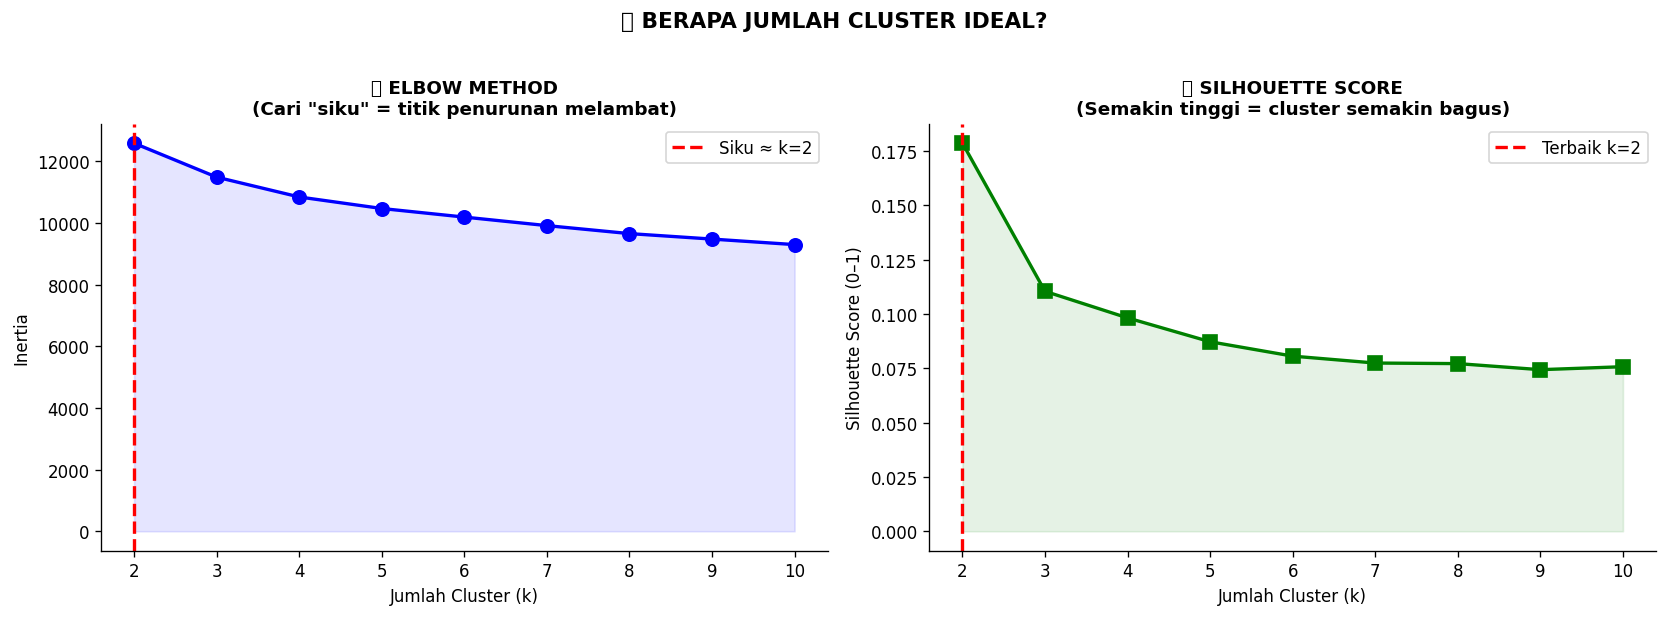


📌 Rekomendasi Elbow     : k = 2
📌 Rekomendasi Silhouette: k = 2


In [13]:
# 12. ELBOW + SILHOUETTE
# ==============================================================================
print("⏳ Mencari jumlah cluster optimal...")

inertia_list    = []
silhouette_list = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia_list, 'bo-', linewidth=2, markersize=8)
ax1.fill_between(k_range, inertia_list, alpha=0.1, color='blue')
ax1.set_title('📐 ELBOW METHOD\n(Cari "siku" = titik penurunan melambat)',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Jumlah Cluster (k)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(list(k_range))
ax1.spines[['top','right']].set_visible(False)

diffs     = np.diff(inertia_list)
diffs2    = np.diff(diffs)
elbow_idx = np.argmax(diffs2) + 2
ax1.axvline(elbow_idx, color='red', linestyle='--', linewidth=2, label=f'Siku ≈ k={elbow_idx}')
ax1.legend()

best_k_sil = list(k_range)[np.argmax(silhouette_list)]
ax2.plot(k_range, silhouette_list, 'gs-', linewidth=2, markersize=8)
ax2.fill_between(k_range, silhouette_list, alpha=0.1, color='green')
ax2.set_title('⭐ SILHOUETTE SCORE\n(Semakin tinggi = cluster semakin bagus)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Jumlah Cluster (k)')
ax2.set_ylabel('Silhouette Score (0–1)')
ax2.set_xticks(list(k_range))
ax2.axvline(best_k_sil, color='red', linestyle='--', linewidth=2, label=f'Terbaik k={best_k_sil}')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

fig.suptitle('🔢 BERAPA JUMLAH CLUSTER IDEAL?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📌 Rekomendasi Elbow     : k = {elbow_idx}")
print(f"📌 Rekomendasi Silhouette: k = {best_k_sil}")

In [14]:
# 13. KMEANS CLUSTERING
# ==============================================================================
K_OPTIMAL = best_k_sil

kmeans = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=20, random_state=42)
kmeans.fit(X_scaled)

X_index = X.index
df_encoded.loc[X_index, 'cluster'] = kmeans.labels_
df.loc[X_index, 'cluster']         = kmeans.labels_
df['cluster'] = df['cluster'].astype('Int64')

sil = silhouette_score(X_scaled, kmeans.labels_)
db  = davies_bouldin_score(X_scaled, kmeans.labels_)

print(f"\n✅ KMeans selesai (k={K_OPTIMAL})")
print(f"   Silhouette Score  : {sil:.4f}  (ideal → 1.0)")
print(f"   Davies-Bouldin    : {db:.4f}  (ideal → 0.0)")
print(f"\n📋 Distribusi anggota per cluster:")
print(df['cluster'].value_counts().sort_index().rename(index=lambda x: f"Cluster {x}").to_string())


✅ KMeans selesai (k=2)
   Silhouette Score  : 0.1702  (ideal → 1.0)
   Davies-Bouldin    : 2.0157  (ideal → 0.0)

📋 Distribusi anggota per cluster:
cluster
Cluster 0    731
Cluster 1    269


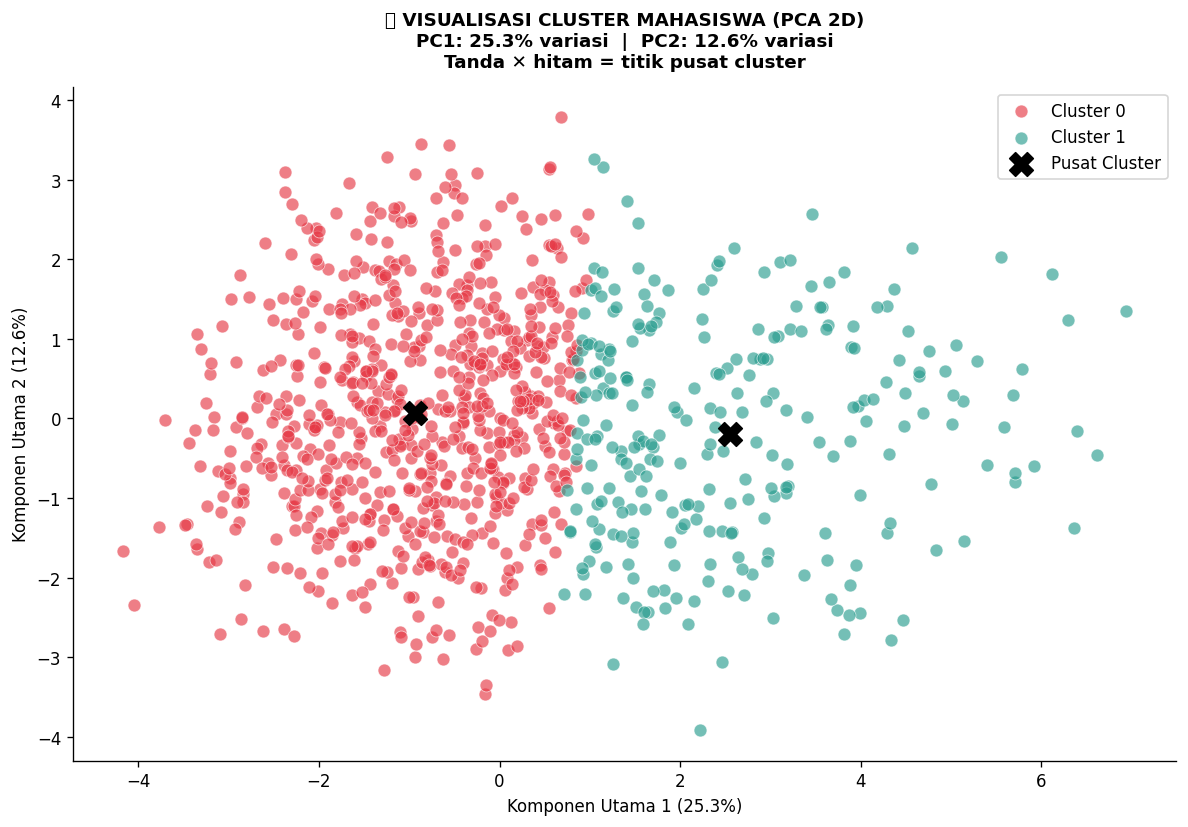

In [15]:
# 14. PCA VISUALISASI 2D
# ==============================================================================
CLUSTER_COLORS = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#F4A261', '#A8DADC']

pca          = PCA(n_components=2, random_state=42)
X_pca        = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))
cluster_labels = sorted(df.loc[X_index, 'cluster'].dropna().unique())

for cl in cluster_labels:
    idx = kmeans.labels_ == cl
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=CLUSTER_COLORS[int(cl) % len(CLUSTER_COLORS)],
               label=f'Cluster {int(cl)}',
               alpha=0.65, s=60, edgecolors='white', linewidth=0.5)

centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', marker='X', s=200, zorder=5, label='Pusat Cluster')

ax.set_title(
    f'🔵 VISUALISASI CLUSTER MAHASISWA (PCA 2D)\n'
    f'PC1: {var_explained[0]:.1f}% variasi  |  PC2: {var_explained[1]:.1f}% variasi\n'
    f'Tanda ✕ hitam = titik pusat cluster',
    fontsize=11, fontweight='bold', pad=12
)
ax.set_xlabel(f'Komponen Utama 1 ({var_explained[0]:.1f}%)', fontsize=10)
ax.set_ylabel(f'Komponen Utama 2 ({var_explained[1]:.1f}%)', fontsize=10)
ax.legend(fontsize=10, framealpha=0.8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


📋 RATA-RATA PER CLUSTER (dalam Rupiah):
         total_pemasukan  total_pengeluaran  sisa_uang  rasio_pengeluaran  pendidikan  tempat_tinggal   makanan  hiburan  teknologi  financial_score
cluster                                                                                                                                             
0              6164896.0          2120829.0  4044067.0                0.0    496970.0        774903.0  265060.0  84187.0   117596.0             72.0
1              3701318.0          2229552.0  1471766.0                1.0    518418.0        834021.0  279066.0  83971.0   122745.0             51.0


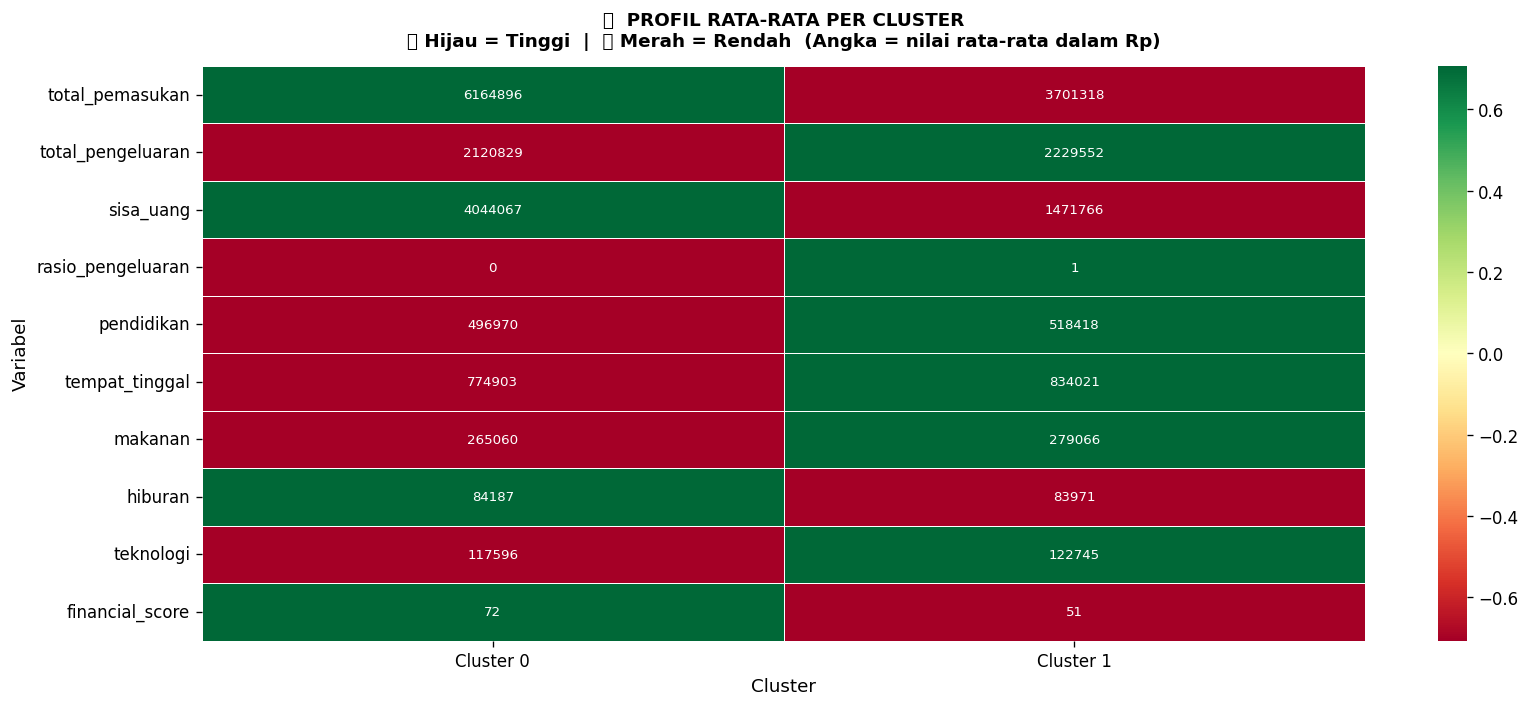

In [16]:
# 15. PROFIL CLUSTER — HEATMAP
# ==============================================================================
kolom_profil = ['total_pemasukan', 'total_pengeluaran', 'sisa_uang',
                'rasio_pengeluaran', 'pendidikan', 'tempat_tinggal',
                'makanan', 'hiburan', 'teknologi', 'financial_score']
kolom_profil = [c for c in kolom_profil if c in df.columns]

profil = df.groupby('cluster')[kolom_profil].mean().round(0)

print("\n📋 RATA-RATA PER CLUSTER (dalam Rupiah):")
print(profil.to_string())

profil_norm = (profil - profil.mean()) / profil.std()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    profil_norm.T,
    annot=profil.T,
    fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title(
    '🗺️  PROFIL RATA-RATA PER CLUSTER\n'
    '🟢 Hijau = Tinggi  |  🔴 Merah = Rendah  (Angka = nilai rata-rata dalam Rp)',
    fontsize=11, fontweight='bold', pad=12
)
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylabel('Variabel', fontsize=11)
ax.set_xticklabels([f'Cluster {int(c)}' for c in profil.index], rotation=0)
plt.tight_layout()
plt.show()

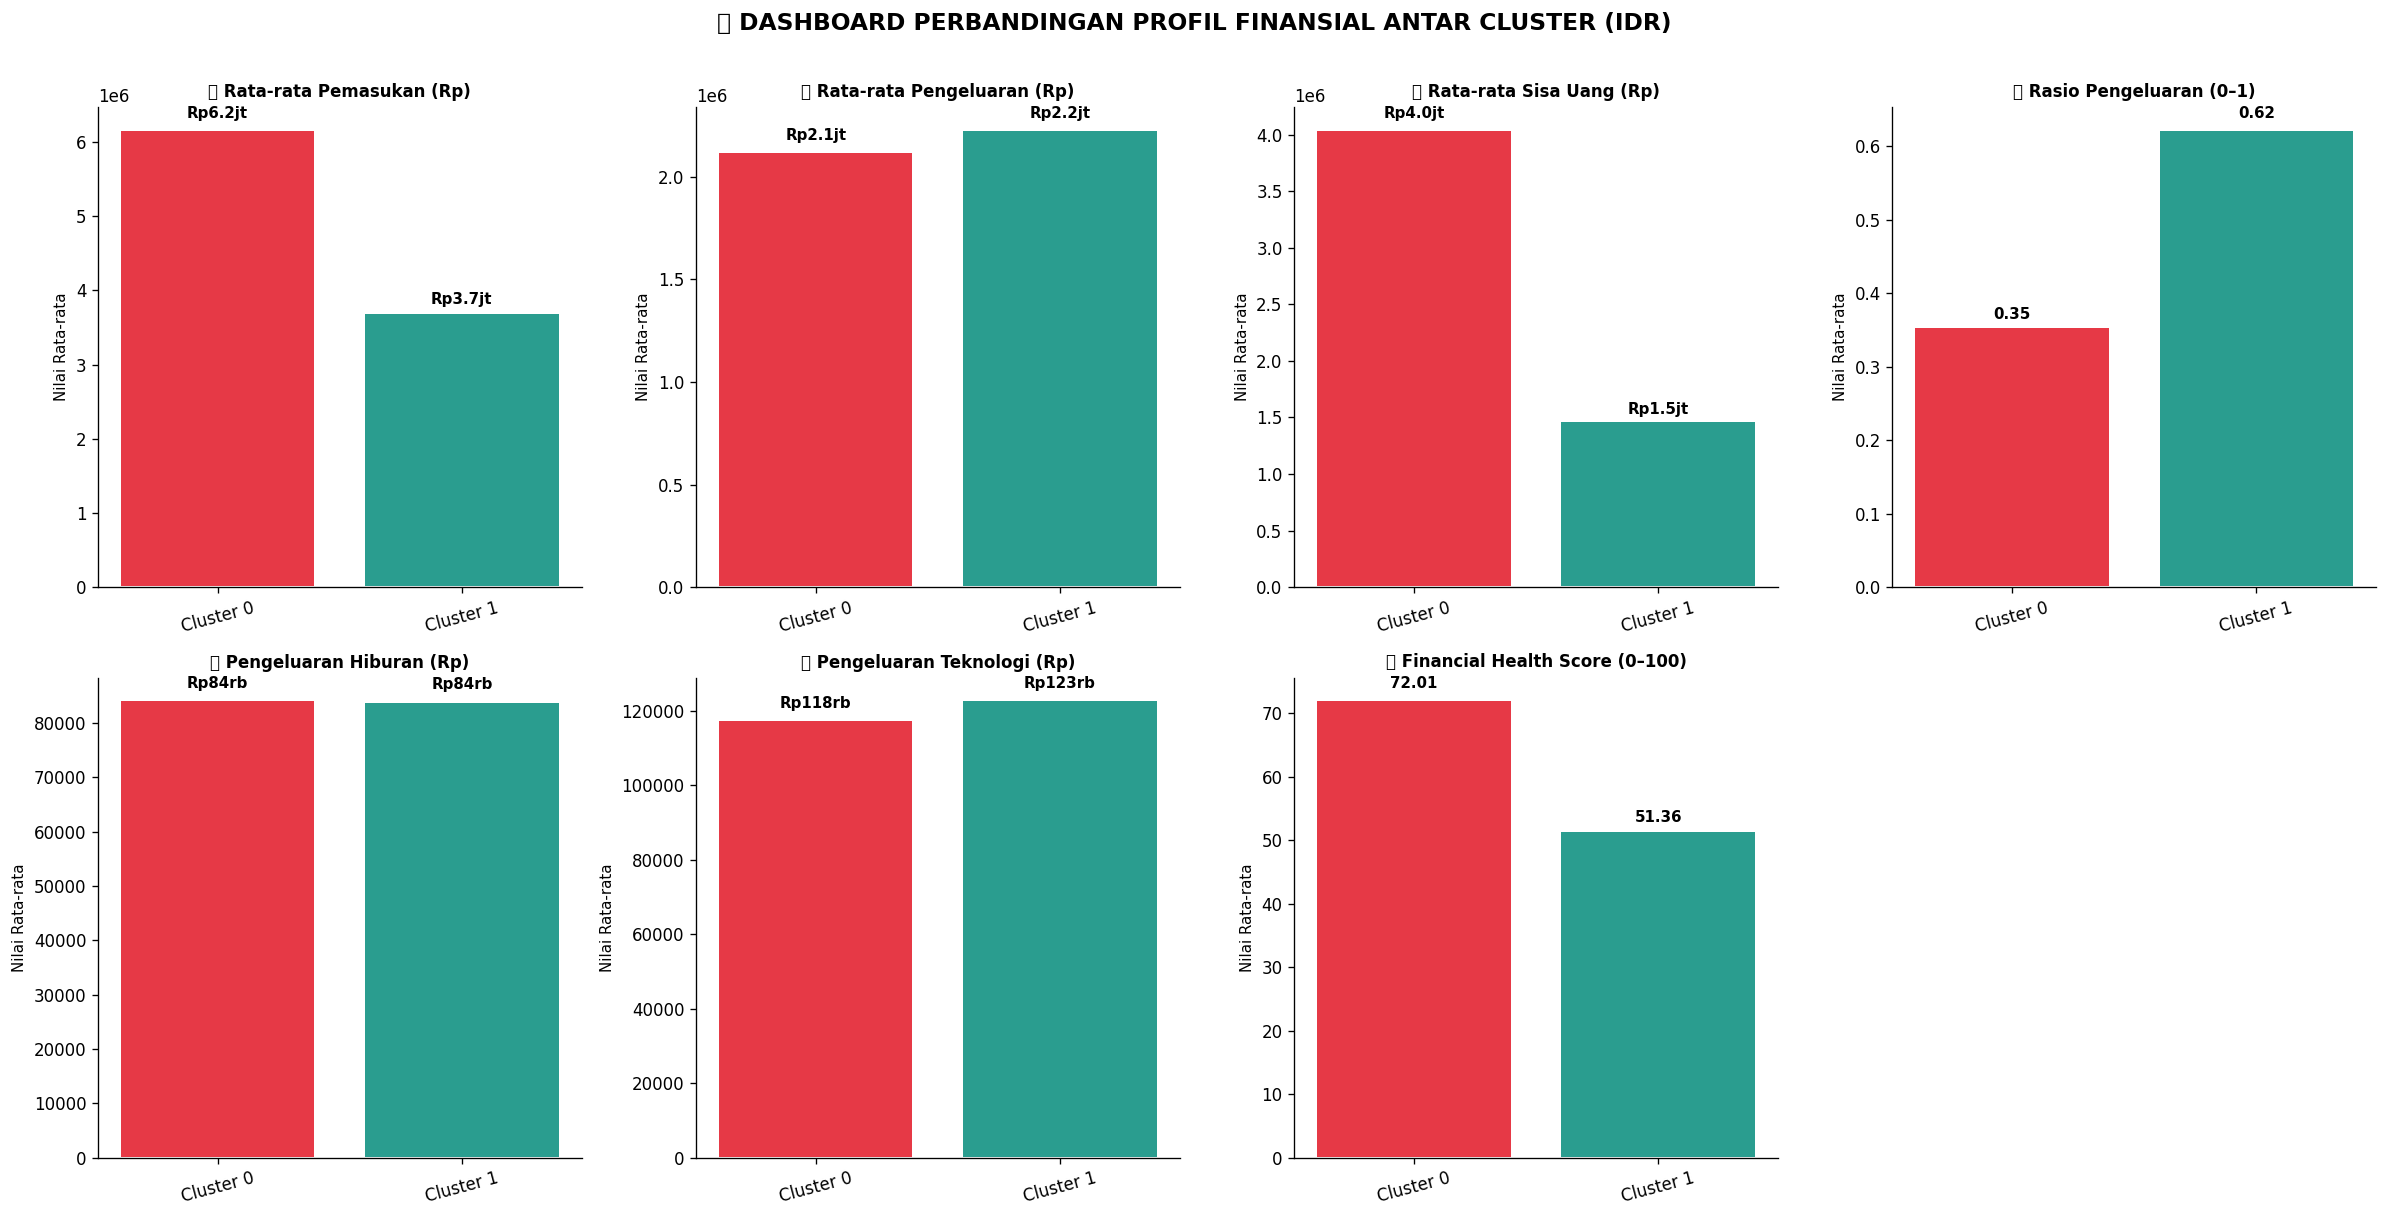

In [17]:
# 16. DASHBOARD BAR PER CLUSTER (IDR)
# ==============================================================================
cols_to_plot = ['total_pemasukan', 'total_pengeluaran', 'sisa_uang',
                'rasio_pengeluaran', 'hiburan', 'teknologi', 'financial_score']
cols_to_plot = [c for c in cols_to_plot if c in df.columns]

judul_cols = {
    'total_pemasukan'   : '💵 Rata-rata Pemasukan (Rp)',
    'total_pengeluaran' : '💸 Rata-rata Pengeluaran (Rp)',
    'sisa_uang'         : '🏦 Rata-rata Sisa Uang (Rp)',
    'rasio_pengeluaran' : '📉 Rasio Pengeluaran (0–1)',
    'hiburan'           : '🎉 Pengeluaran Hiburan (Rp)',
    'teknologi'         : '💻 Pengeluaran Teknologi (Rp)',
    'financial_score'   : '🩺 Financial Health Score (0–100)',
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    vals       = df.groupby('cluster')[col].mean()
    colors_bar = [CLUSTER_COLORS[int(c) % len(CLUSTER_COLORS)] for c in vals.index]
    bars       = ax.bar([f'Cluster {int(c)}' for c in vals.index],
                        vals.values, color=colors_bar, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, vals.values):
        if col in ['rasio_pengeluaran', 'financial_score']:
            label = f'{val:.2f}'
        elif val >= 1_000_000:
            label = f'Rp{val/1_000_000:.1f}jt'
        else:
            label = f'Rp{val/1_000:.0f}rb'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(judul_cols.get(col, col), fontsize=10, fontweight='bold')
    ax.set_ylabel('Nilai Rata-rata', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', rotation=15)

for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('📊 DASHBOARD PERBANDINGAN PROFIL FINANSIAL ANTAR CLUSTER (IDR)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

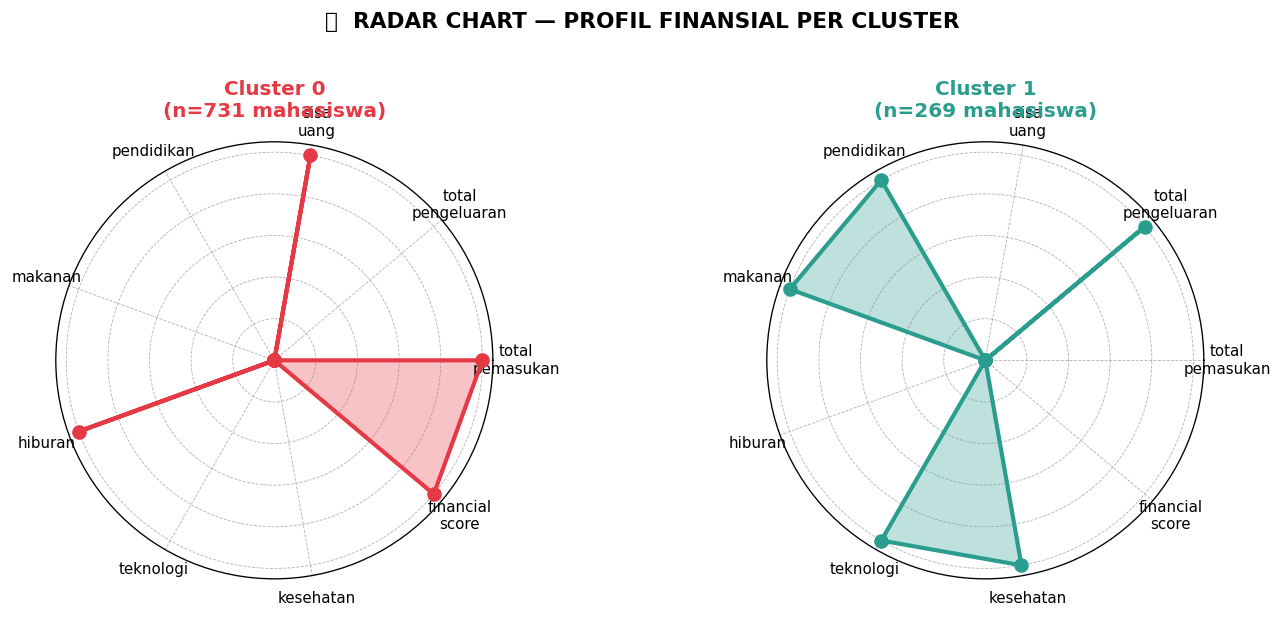

In [18]:
# 17. RADAR CHART
# ==============================================================================
fitur_radar = ['total_pemasukan', 'total_pengeluaran', 'sisa_uang',
               'pendidikan', 'makanan', 'hiburan', 'teknologi', 'kesehatan', 'financial_score']
fitur_radar = [c for c in fitur_radar if c in df.columns]
label_radar = [c.replace('_', '\n') for c in fitur_radar]

profil_radar      = df.groupby('cluster')[fitur_radar].mean()
profil_radar_norm = (profil_radar - profil_radar.min()) / (profil_radar.max() - profil_radar.min() + 1e-9)

angles  = np.linspace(0, 2 * np.pi, len(fitur_radar), endpoint=False).tolist()
angles += angles[:1]

cluster_list = sorted(profil_radar.index.dropna())
n_clusters   = len(cluster_list)
cols_r       = min(n_clusters, 3)
rows_r       = (n_clusters + cols_r - 1) // cols_r

fig, axes = plt.subplots(rows_r, cols_r, figsize=(6 * cols_r, 5 * rows_r),
                          subplot_kw=dict(polar=True))
if n_clusters == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for ax, cl in zip(axes, cluster_list):
    values  = profil_radar_norm.loc[cl].tolist()
    values += values[:1]
    color   = CLUSTER_COLORS[int(cl) % len(CLUSTER_COLORS)]

    ax.fill(angles, values, color=color, alpha=0.3)
    ax.plot(angles, values, color=color, linewidth=2.5)
    ax.scatter(angles[:-1], values[:-1], color=color, s=60, zorder=5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(label_radar, size=9)
    ax.set_yticklabels([])
    ax.set_title(f'Cluster {int(cl)}\n(n={int((df["cluster"]==cl).sum())} mahasiswa)',
                 fontsize=12, fontweight='bold', pad=15, color=color)
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.6)

for ax in axes[len(cluster_list):]:
    ax.set_visible(False)

fig.suptitle('🕸️  RADAR CHART — PROFIL FINANSIAL PER CLUSTER',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# 18. INTERPRETASI & PENAMAAN CLUSTER
# ==============================================================================
print("\n" + "=" * 60)
print("🏷️  INTERPRETASI & PENAMAAN CLUSTER")
print("=" * 60)

nama_cluster   = {}
sisa_rata      = profil['sisa_uang']
rasio_rata     = profil['rasio_pengeluaran']
pendapatan_rata = profil['total_pemasukan']
skor_rata      = profil['financial_score']

rank_sisa      = sisa_rata.rank(ascending=False)
rank_rasio     = rasio_rata.rank(ascending=True)
rank_pendapatan = pendapatan_rata.rank(ascending=False)

for cl in cluster_list:
    r_sisa = rank_sisa[cl]
    r_rasio = rank_rasio[cl]
    r_pend  = rank_pendapatan[cl]

    if r_sisa <= 1 and r_pend <= 1:
        label = "Mahasiswa Mapan & Hemat"
    elif r_sisa <= 1:
        label = "Mahasiswa Hemat"
    elif r_pend <= 1 and r_rasio >= n_clusters:
        label = "Mahasiswa Berpenghasilan Tinggi & Boros"
    elif r_rasio >= n_clusters:
        label = "Mahasiswa Boros / Defisit"
    elif r_pend >= n_clusters:
        label = "Mahasiswa Berpenghasilan Rendah"
    else:
        label = "Mahasiswa Rata-rata"

    nama_cluster[cl] = label
    avg_score = skor_rata[cl]
    status    = get_status(avg_score)

    print(f"\nCluster {int(cl)}: {label}")
    print(f"   • Pemasukan rata-rata   : Rp{pendapatan_rata[cl]/1_000_000:.2f} jt")
    print(f"   • Pengeluaran rata-rata : Rp{profil['total_pengeluaran'][cl]/1_000_000:.2f} jt")
    print(f"   • Sisa uang rata-rata   : Rp{sisa_rata[cl]/1_000_000:.2f} jt")
    print(f"   • Rasio pengeluaran     : {rasio_rata[cl]:.2f} ({'Boros 🔴' if rasio_rata[cl] > 0.9 else 'Seimbang 🟡' if rasio_rata[cl] > 0.7 else 'Hemat 🟢'})")
    print(f"   • Financial Score (avg) : {avg_score:.1f} → Status: {status}")
    print(f"   • Jumlah mahasiswa      : {int((df['cluster']==cl).sum())}")

df['nama_cluster'] = df['cluster'].map(nama_cluster)


🏷️  INTERPRETASI & PENAMAAN CLUSTER

Cluster 0: Mahasiswa Mapan & Hemat
   • Pemasukan rata-rata   : Rp6.16 jt
   • Pengeluaran rata-rata : Rp2.12 jt
   • Sisa uang rata-rata   : Rp4.04 jt
   • Rasio pengeluaran     : 0.00 (Hemat 🟢)
   • Financial Score (avg) : 72.0 → Status: Stabil
   • Jumlah mahasiswa      : 731

Cluster 1: Mahasiswa Boros / Defisit
   • Pemasukan rata-rata   : Rp3.70 jt
   • Pengeluaran rata-rata : Rp2.23 jt
   • Sisa uang rata-rata   : Rp1.47 jt
   • Rasio pengeluaran     : 1.00 (Boros 🔴)
   • Financial Score (avg) : 51.0 → Status: Bahaya
   • Jumlah mahasiswa      : 269


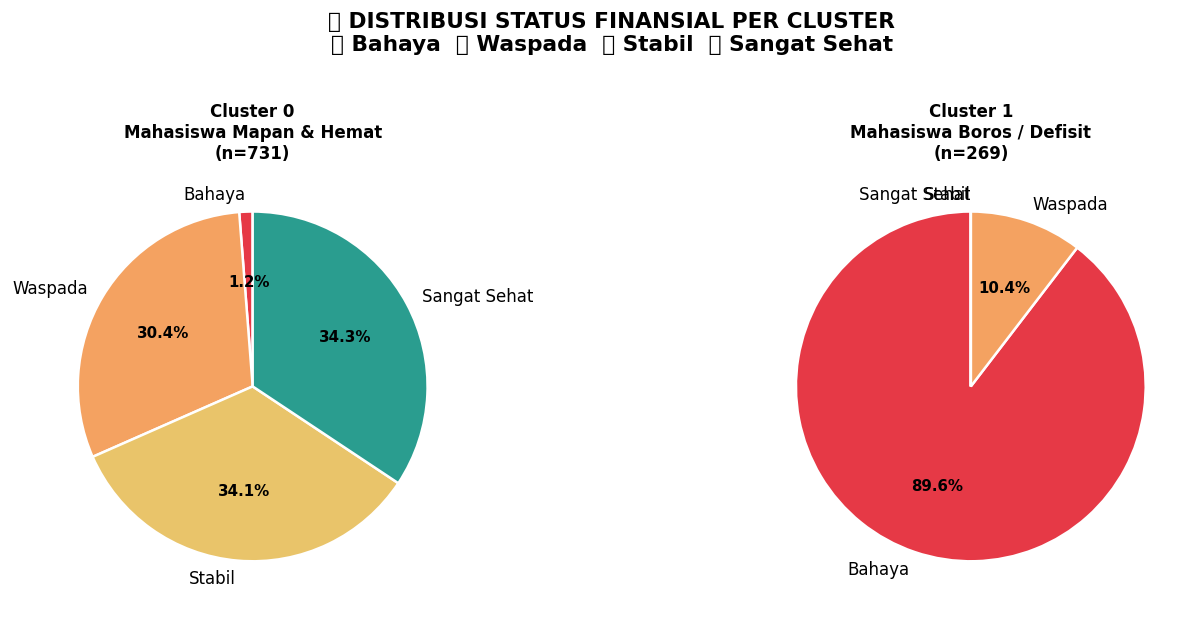

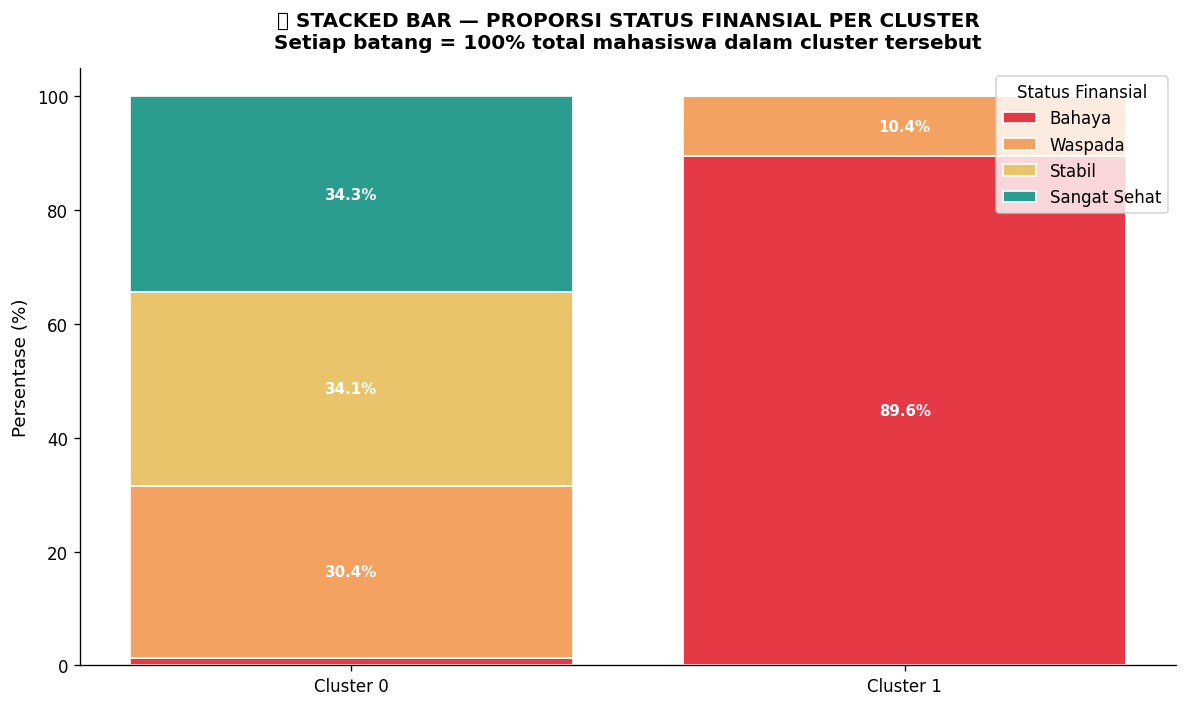

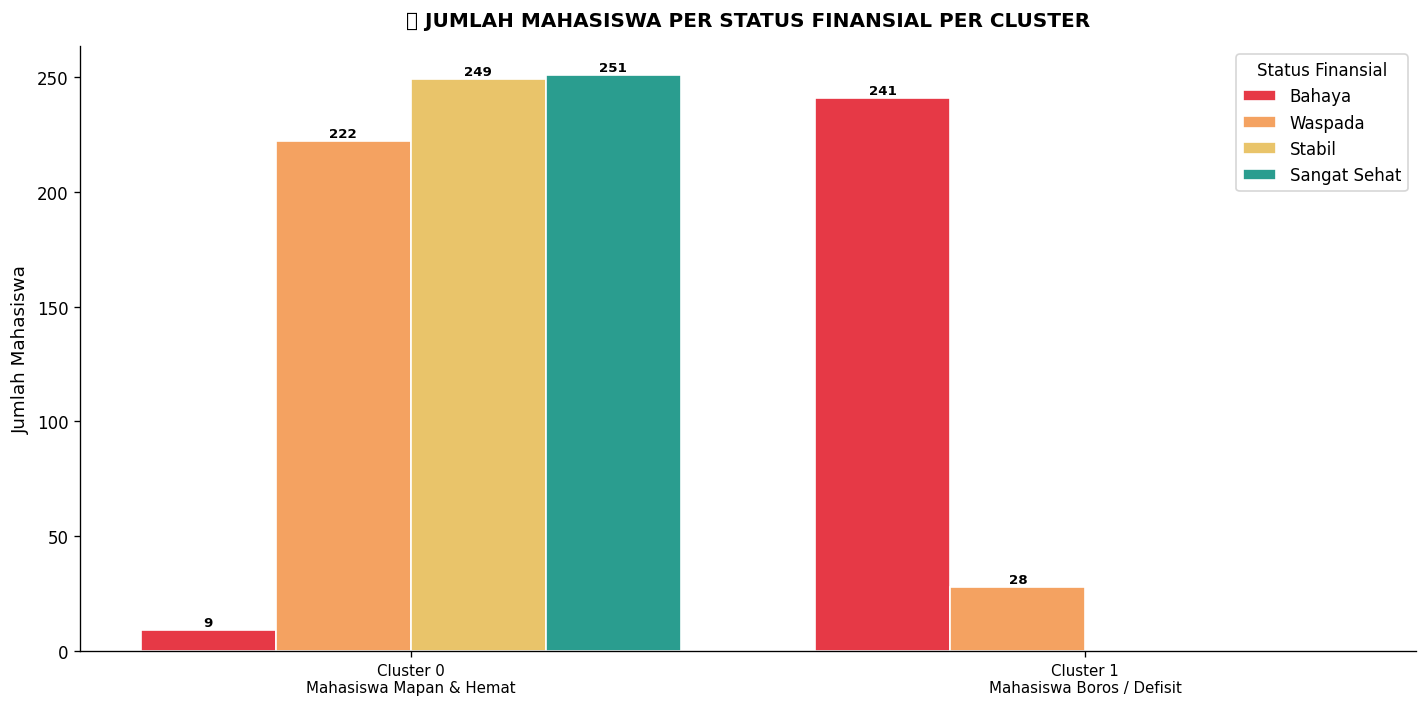

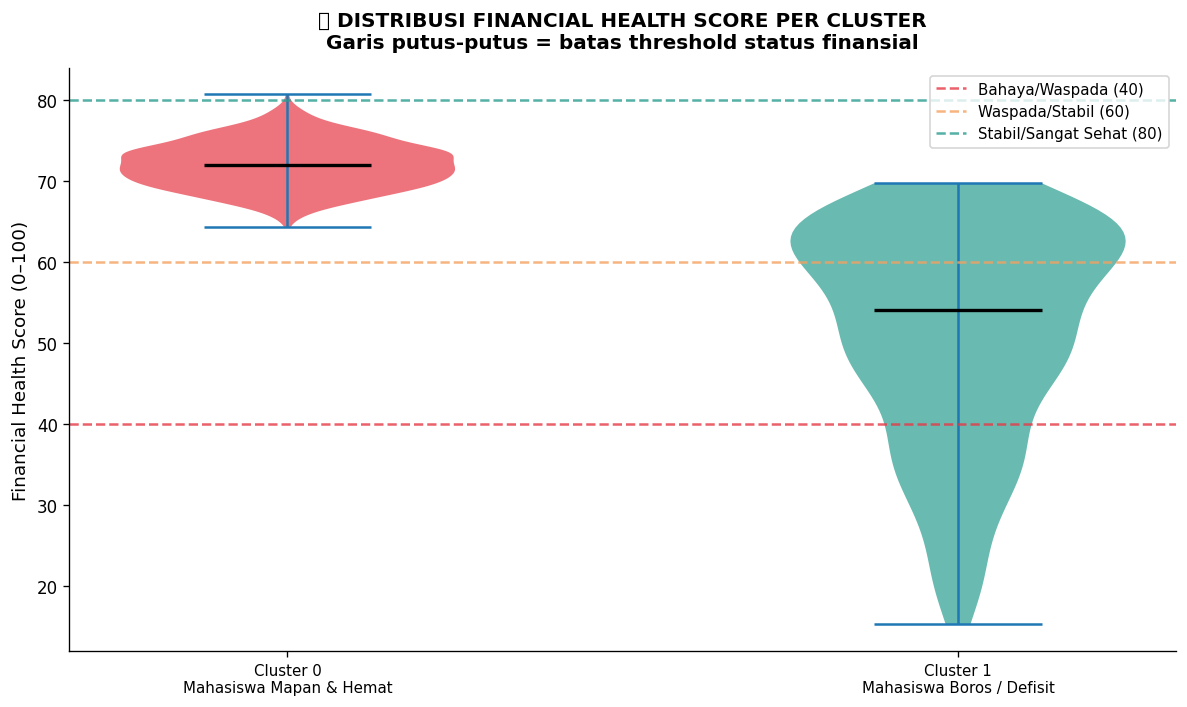

In [20]:
# 19. DISTRIBUSI STATUS PER CLUSTER (PIE + BAR + STACKED)
# ==============================================================================

# --- 19a. Pie chart status per cluster ---
n_cl   = len(cluster_list)
cols_p = min(n_cl, 3)
rows_p = (n_cl + cols_p - 1) // cols_p

fig, axes = plt.subplots(rows_p, cols_p, figsize=(6 * cols_p, 5 * rows_p))
if n_cl == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for ax, cl in zip(axes, cluster_list):
    subset = df[df['cluster'] == cl]['status_finansial']
    counts = subset.value_counts().reindex(STATUS_ORDER, fill_value=0)
    pcts   = counts / counts.sum() * 100

    color_list = [STATUS_COLORS[s] for s in STATUS_ORDER]
    wedges, texts, autotexts = ax.pie(
        pcts, labels=STATUS_ORDER,
        colors=color_list,
        autopct=lambda p: f'{p:.1f}%' if p > 0 else '',
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for t in autotexts:
        t.set_fontsize(9)
        t.set_fontweight('bold')

    nama = nama_cluster.get(cl, f'Cluster {int(cl)}')
    ax.set_title(f'Cluster {int(cl)}\n{nama}\n(n={len(subset)})',
                 fontsize=10, fontweight='bold')

for ax in axes[len(cluster_list):]:
    ax.set_visible(False)

fig.suptitle('🩺 DISTRIBUSI STATUS FINANSIAL PER CLUSTER\n'
             '🔴 Bahaya  🟠 Waspada  🟡 Stabil  🟢 Sangat Sehat',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- 19b. Stacked bar — proporsi status per cluster ---
status_counts = df.groupby(['cluster', 'status_finansial']).size().unstack(fill_value=0)
status_counts = status_counts.reindex(columns=STATUS_ORDER, fill_value=0)
status_pct    = status_counts.div(status_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(status_pct))
cluster_ticks = [f'Cluster {int(c)}' for c in status_pct.index]

for status in STATUS_ORDER:
    vals = status_pct[status].values
    bars = ax.bar(cluster_ticks, vals, bottom=bottom,
                  color=STATUS_COLORS[status], label=status,
                  edgecolor='white', linewidth=1)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 4:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bottom[i] + val/2,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
    bottom += vals

ax.set_title('📊 STACKED BAR — PROPORSI STATUS FINANSIAL PER CLUSTER\n'
             'Setiap batang = 100% total mahasiswa dalam cluster tersebut',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Persentase (%)', fontsize=11)
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=10, title='Status Finansial')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# --- 19c. Grouped bar — jumlah mahasiswa per status per cluster ---
fig, ax = plt.subplots(figsize=(12, 6))
x      = np.arange(len(cluster_list))
width  = 0.2
n_stat = len(STATUS_ORDER)

for i, status in enumerate(STATUS_ORDER):
    vals = [status_counts.loc[cl, status] if cl in status_counts.index else 0
            for cl in cluster_list]
    offset = (i - n_stat/2 + 0.5) * width
    bars   = ax.bar(x + offset, vals, width,
                    label=status, color=STATUS_COLORS[status],
                    edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {int(c)}\n{nama_cluster.get(c,"")}' for c in cluster_list],
                   fontsize=9)
ax.set_title('👥 JUMLAH MAHASISWA PER STATUS FINANSIAL PER CLUSTER',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Jumlah Mahasiswa', fontsize=11)
ax.legend(title='Status Finansial', fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# --- 19d. Distribusi financial_score per cluster (violin) ---
fig, ax = plt.subplots(figsize=(10, 6))
df_plot = df.dropna(subset=['cluster', 'financial_score'])
violin_data = [df_plot[df_plot['cluster'] == cl]['financial_score'].values for cl in cluster_list]
parts = ax.violinplot(violin_data, positions=range(len(cluster_list)), showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(CLUSTER_COLORS[i % len(CLUSTER_COLORS)])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

# Tambahkan threshold garis status
thresholds = {'Bahaya/Waspada': 40, 'Waspada/Stabil': 60, 'Stabil/Sangat Sehat': 80}
th_colors  = {'Bahaya/Waspada': '#E63946', 'Waspada/Stabil': '#F4A261', 'Stabil/Sangat Sehat': '#2A9D8F'}
for label, threshold in thresholds.items():
    ax.axhline(threshold, linestyle='--', linewidth=1.5, color=th_colors[label], label=f'{label} ({threshold})', alpha=0.8)

ax.set_xticks(range(len(cluster_list)))
ax.set_xticklabels([f'Cluster {int(c)}\n{nama_cluster.get(c,"")}' for c in cluster_list], fontsize=9)
ax.set_title('🎻 DISTRIBUSI FINANCIAL HEALTH SCORE PER CLUSTER\n'
             'Garis putus-putus = batas threshold status finansial',
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Financial Health Score (0–100)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()


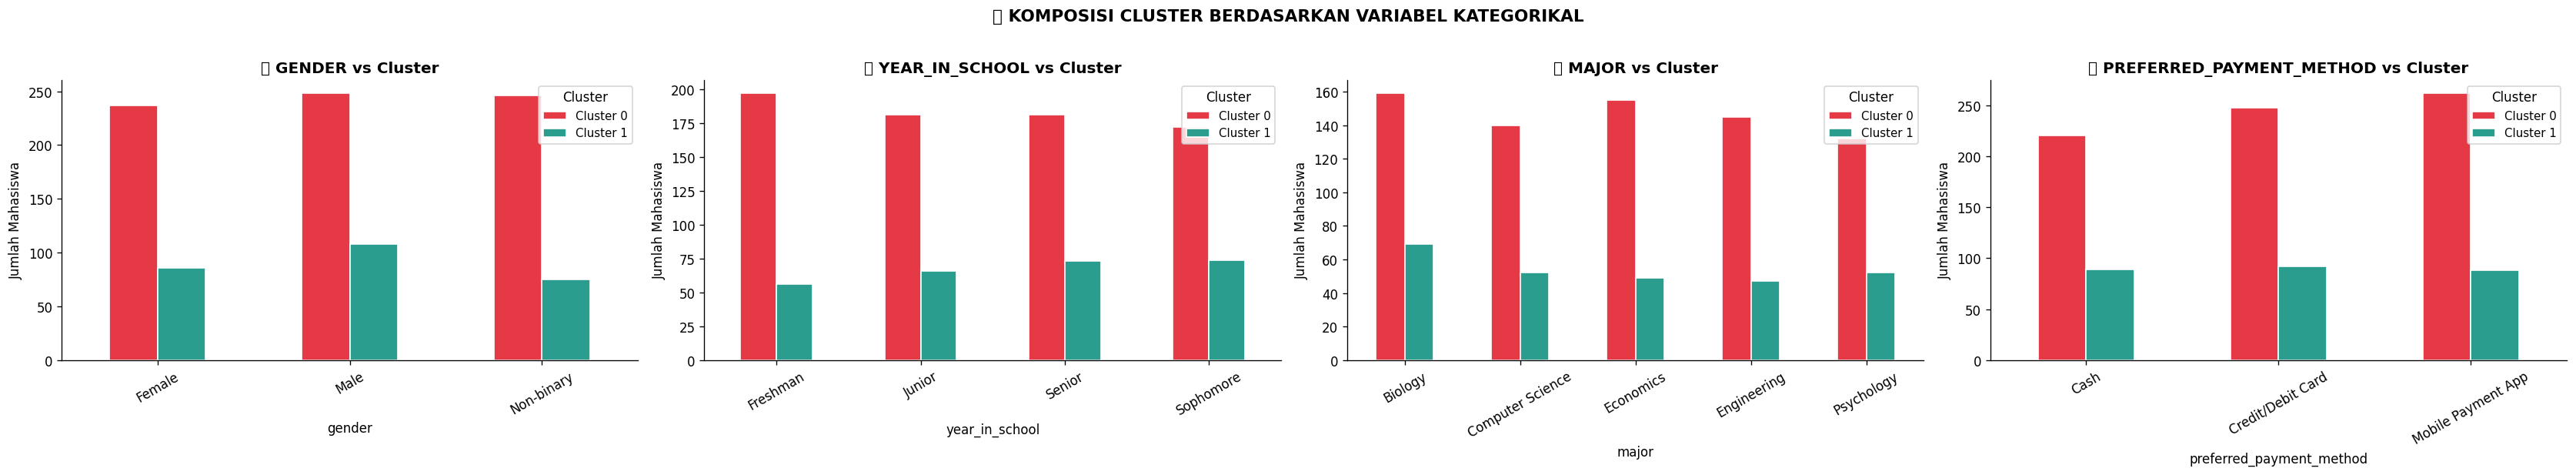


📋  RINGKASAN AKHIR — CLUSTERING FINANSIAL MAHASISWA (IDR)
• Dataset         : Student Spending Dataset (Kaggle, dikondisikan IDR)
• Kurs referensi  : 1 USD = Rp 18,035 + rasio biaya hidup Indonesia
• Jumlah data     : 1,000 mahasiswa
• Fitur clustering: 15 fitur
• Algoritma       : KMeans (k=2)
• Silhouette Score: 0.1702
• Davies-Bouldin  : 2.0157

📌 Daftar Cluster, Nama & Distribusi Status Finansial:

   Cluster 0 (731 orang) → Mahasiswa Mapan & Hemat
   Avg Financial Score: 72.0 → Stabil
     Bahaya        :   1.2%  
     Waspada       :  30.4%  ██████
     Stabil        :  34.1%  ██████
     Sangat Sehat  :  34.3%  ██████

   Cluster 1 (269 orang) → Mahasiswa Boros / Defisit
   Avg Financial Score: 51.4 → Bahaya
     Bahaya        :  89.6%  █████████████████
     Waspada       :  10.4%  ██
     Stabil        :   0.0%  
     Sangat Sehat  :   0.0%  

✅ Data disimpan ke: /tmp/hasil_clustering_finansial_IDR.csv
   Kolom tambahan: 'cluster', 'nama_cluster', 'financial_score', 'status_f

In [21]:
# 20. CROSSTAB KATEGORIKAL vs CLUSTER
# ==============================================================================
if len(categorical_cols) > 0:
    fig, axes = plt.subplots(1, len(categorical_cols),
                              figsize=(7 * len(categorical_cols), 5))
    if len(categorical_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, categorical_cols):
        ct = pd.crosstab(df[col], df['cluster'])
        ct.columns = [f'Cluster {int(c)}' for c in ct.columns]
        ct.plot(kind='bar', ax=ax, color=CLUSTER_COLORS[:len(ct.columns)],
                edgecolor='white', linewidth=1)
        ax.set_title(f'📌 {col.upper()} vs Cluster', fontsize=12, fontweight='bold')
        ax.set_xlabel(col, fontsize=10)
        ax.set_ylabel('Jumlah Mahasiswa', fontsize=10)
        ax.tick_params(axis='x', rotation=30)
        ax.legend(title='Cluster', fontsize=9)
        ax.spines[['top','right']].set_visible(False)

    fig.suptitle('👥 KOMPOSISI CLUSTER BERDASARKAN VARIABEL KATEGORIKAL',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 21. RINGKASAN AKHIR
# ==============================================================================
print("\n" + "=" * 65)
print("📋  RINGKASAN AKHIR — CLUSTERING FINANSIAL MAHASISWA (IDR)")
print("=" * 65)
print(f"• Dataset         : Student Spending Dataset (Kaggle, dikondisikan IDR)")
print(f"• Kurs referensi  : 1 USD = Rp {KURS_USD_IDR:,} + rasio biaya hidup Indonesia")
print(f"• Jumlah data     : {len(df):,} mahasiswa")
print(f"• Fitur clustering: {len(fitur_clustering)} fitur")
print(f"• Algoritma       : KMeans (k={K_OPTIMAL})")
print(f"• Silhouette Score: {sil:.4f}")
print(f"• Davies-Bouldin  : {db:.4f}")

print(f"\n📌 Daftar Cluster, Nama & Distribusi Status Finansial:")
for cl in cluster_list:
    nm      = nama_cluster.get(cl, f'Cluster {int(cl)}')
    n_cl_   = int((df['cluster'] == cl).sum())
    subset  = df[df['cluster'] == cl]
    pcts_cl = subset['status_finansial'].value_counts(normalize=True).reindex(STATUS_ORDER, fill_value=0) * 100
    avg_sc  = subset['financial_score'].mean()

    print(f"\n   Cluster {int(cl)} ({n_cl_} orang) → {nm}")
    print(f"   Avg Financial Score: {avg_sc:.1f} → {get_status(avg_sc)}")
    for s in STATUS_ORDER:
        bar = "█" * int(pcts_cl[s] / 5)
        print(f"     {s:<14}: {pcts_cl[s]:>5.1f}%  {bar}")

# Ekspor
output_path = '/tmp/hasil_clustering_finansial_IDR.csv'
df.to_csv(output_path, index=False)
print(f"\n✅ Data disimpan ke: {output_path}")
print("   Kolom tambahan: 'cluster', 'nama_cluster', 'financial_score', 'status_finansial'")
print("\n🎉 SELESAI! Clustering Finansial Mahasiswa Indonesia berhasil dijalankan.")

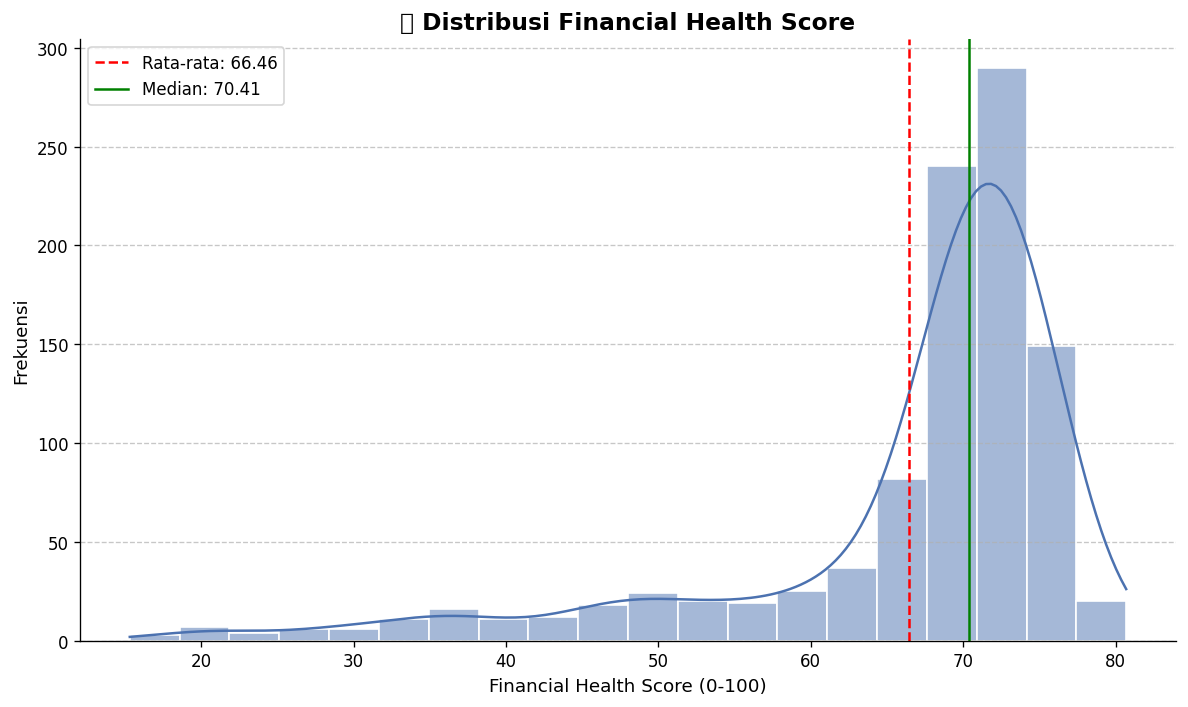

In [22]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(df['financial_score'], bins=20, kde=True, color='#4C72B0', edgecolor='white')
ax.set_title('📊 Distribusi Financial Health Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Financial Health Score (0-100)', fontsize=11)
ax.set_ylabel('Frekuensi', fontsize=11)
ax.axvline(df['financial_score'].mean(), color='red', linestyle='--', label=f'Rata-rata: {df['financial_score'].mean():.2f}')
ax.axvline(df['financial_score'].median(), color='green', linestyle='-', label=f'Median: {df['financial_score'].median():.2f}')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()